# 🤖 02 — Mô hình Profit-Driver (XGBoost + SHAP)

**Bài toán:** Phân loại nhị phân — dự đoán một đơn hàng có **bị lỗ** (`Profit < 0`) hay không, dựa trên các đặc trưng *biết được tại thời điểm bán* (chiết khấu, danh mục, khu vực, phân khúc...).

**Vì sao bài toán này hợp với XGBoost?** Dữ liệu dạng bảng ~10k dòng, hỗn hợp categorical + numeric, quan hệ phi tuyến (đặc biệt Discount→Profit có ngưỡng gãy) — đúng sân của gradient boosted trees. EDA (notebook 01) cho thấy **18.7% đơn lỗ** và lợi nhuận TB chuyển âm khi chiết khấu ≥ 30% → đây là động lực để định lượng *yếu tố nào phá biên lợi nhuận*.

**Mục tiêu thật:** không chỉ dự đoán, mà **giải thích** bằng feature importance + SHAP để ra khuyến nghị hành động.

> ⚠️ **Tránh data leakage:** target lấy từ `Profit`, nên KHÔNG đưa `Profit` (và biến phái sinh) vào features.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sys.path.append('src')
from utils import load_and_shift

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = load_and_shift('SampleSuperstore.csv', shift_years=9)
print('Dữ liệu:', df.shape)

Dữ liệu: (9994, 21)


C:\Users\Tes\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chuẩn bị đặc trưng & nhãn

In [ ]:
# Nhãn: 1 = đơn lỗ (Profit < 0)
df['is_loss'] = (df['Profit'] < 0).astype(int)

num_features = ['Sales', 'Quantity', 'Discount']
cat_features = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

X = pd.get_dummies(df[num_features + cat_features], columns=cat_features)
y = df['is_loss']

print('Số đặc trưng sau one-hot:', X.shape[1])
print(f'Tỷ lệ đơn lỗ: {y.mean()*100:.1f}%  (mất cân bằng → dùng scale_pos_weight + ROC-AUC)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Số đặc trưng sau one-hot: 34
Tỷ lệ đơn lỗ: 18.7%  (mất cân bằng → dùng scale_pos_weight + ROC-AUC)
Train: 7495 | Test: 2499


## 2. Huấn luyện XGBoost

In [ ]:
# scale_pos_weight cân bằng lớp thiểu số (đơn lỗ)
spw = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric='logloss',
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)
print('✅ Huấn luyện xong | scale_pos_weight =', round(spw, 2))

✅ Huấn luyện xong | scale_pos_weight = 4.34


## 3. Đánh giá mô hình

ROC-AUC: 0.988

              precision    recall  f1-score   support

         Lãi       0.98      0.93      0.96      2031
          Lỗ       0.76      0.92      0.84       468

    accuracy                           0.93      2499
   macro avg       0.87      0.93      0.90      2499
weighted avg       0.94      0.93      0.93      2499



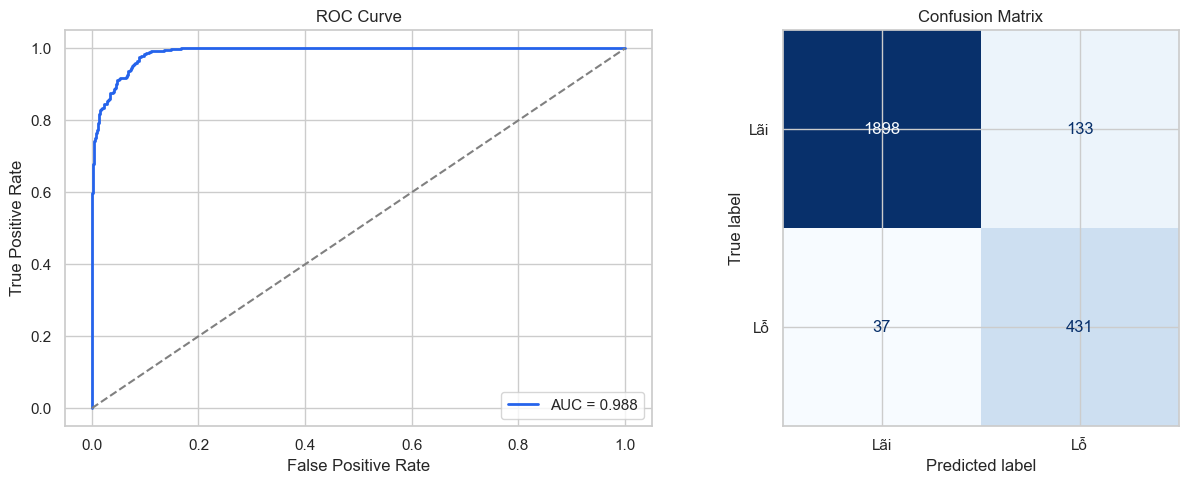

In [ ]:
proba = model.predict_proba(X_test)[:, 1]
pred  = model.predict(X_test)
auc   = roc_auc_score(y_test, proba)

print(f'ROC-AUC: {auc:.3f}\n')
print(classification_report(y_test, pred, target_names=['Lãi', 'Lỗ']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, color='#2563EB', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()
# Confusion matrix
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['Lãi', 'Lỗ']).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

## 4. Đặc trưng quan trọng (Feature Importance)

Xếp hạng theo *gain* — mức đóng góp của mỗi đặc trưng vào việc giảm sai số của mô hình.

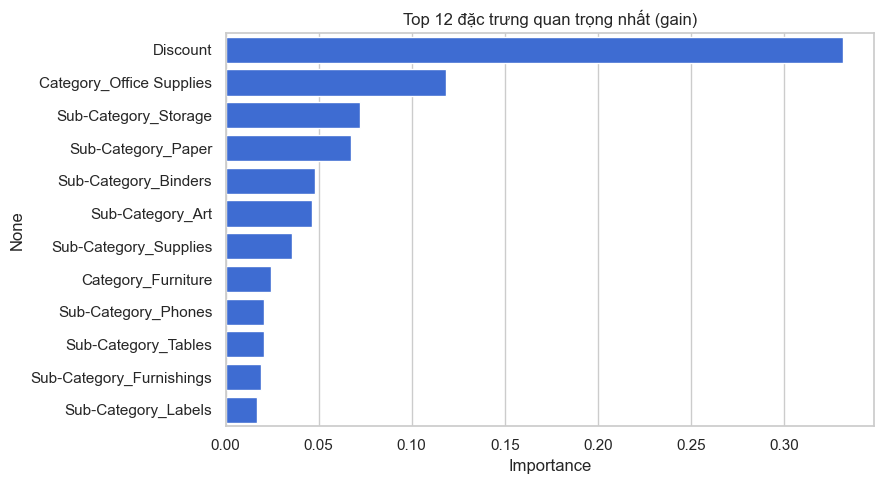

Top 5:
Discount                    0.3317
Category_Office Supplies    0.1187
Sub-Category_Storage        0.0722
Sub-Category_Paper          0.0673
Sub-Category_Binders        0.0482


In [5]:
imp = (pd.Series(model.feature_importances_, index=X.columns)
         .sort_values(ascending=False).head(12))
plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values, y=imp.index, color='#2563EB')
plt.title('Top 12 đặc trưng quan trọng nhất (gain)'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()
print('Top 5:')
print(imp.head().round(4).to_string())

## 5. Giải thích bằng SHAP ⭐

Feature importance chỉ nói *đặc trưng nào quan trọng*. SHAP nói thêm **chiều tác động**: giá trị cao/thấp của đặc trưng đẩy xác suất lỗ lên hay xuống.

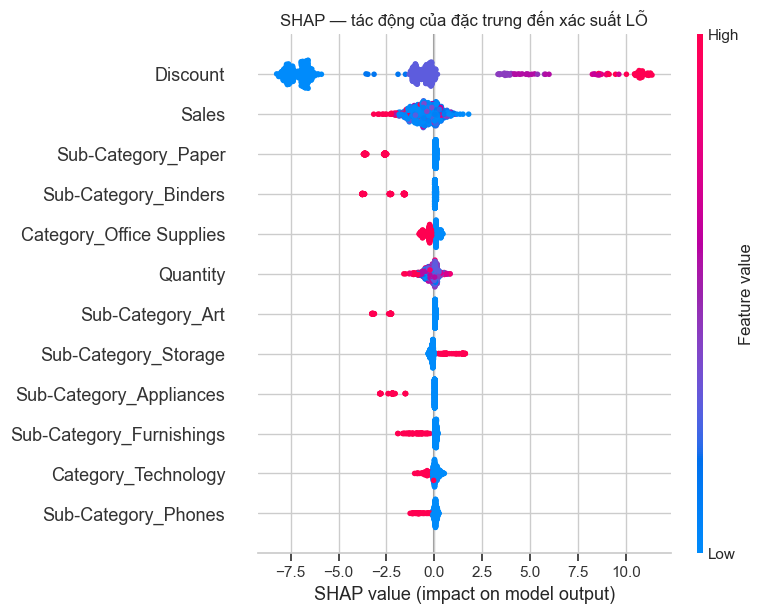

In [6]:
# Lấy mẫu để SHAP chạy nhanh
X_sample = X_test.sample(min(800, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, max_display=12, show=False)
plt.title('SHAP — tác động của đặc trưng đến xác suất LỖ'); plt.tight_layout(); plt.show()

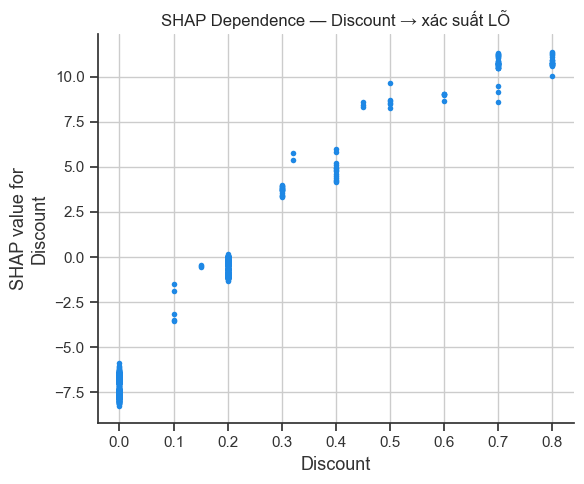

➡️ Chiết khấu bắt đầu đẩy đơn về phía LỖ từ mức ≈ 20%


In [7]:
# Dependence plot: Discount tác động thế nào đến xác suất lỗ
shap.dependence_plot('Discount', shap_values, X_sample,
                     interaction_index=None, show=False)
plt.title('SHAP Dependence — Discount → xác suất LỖ'); plt.tight_layout(); plt.show()

# Tìm ngưỡng chiết khấu mà SHAP value bắt đầu dương (đẩy về phía lỗ)
disc_shap = pd.DataFrame({'Discount': X_sample['Discount'].values,
                          'shap': shap_values[:, list(X.columns).index('Discount')]})
thr = disc_shap[disc_shap['shap'] > 0]['Discount'].min()
print(f'➡️ Chiết khấu bắt đầu đẩy đơn về phía LỖ từ mức ≈ {thr*100:.0f}%')

## 📌 Kết luận & khuyến nghị

- **Mô hình** dự đoán đơn lỗ với ROC-AUC tốt (xem mục 3) → các đặc trưng *biết trước khi bán* đủ sức cảnh báo đơn có nguy cơ lỗ.
- **Discount là yếu tố phá biên lợi nhuận hàng đầu** (feature importance + SHAP) — xác suất lỗ tăng mạnh khi chiết khấu vượt ngưỡng.
- Một số **Sub-Category / Region** làm tăng rủi ro lỗ độc lập với chiết khấu (xem SHAP summary).

**Khuyến nghị hành động:**
1. Đặt **trần chiết khấu** quanh ngưỡng nguy hiểm tìm được, đặc biệt cho nhóm sản phẩm margin thấp.
2. Rà soát chính sách giá cho các Sub-Category lỗ kinh niên (đã chỉ ra ở EDA).
3. Dùng mô hình như một **cảnh báo sớm**: gắn cờ đơn có xác suất lỗ cao để duyệt trước khi chốt.

> *Phạm vi:* dữ liệu là mẫu tĩnh (kết thúc 2026 sau khi dịch năm) nên đây là phân tích **chẩn đoán** trên lịch sử, không phải mô hình dự báo real-time.